# Innovación (bono): mapa de las capitales

**Complemento de la Parte 3.** Este notebook no reemplaza a `cruce_analisis.ipynb`: parte de su resultado, `datos/tabla_final.csv`, y agrega un mapa que pone en el territorio la lluvia, los días de lluvia fuerte y las declaratorias de cada departamento (temporada 2022).

**Aviso sobre los datos:** de las 29 normas que devolvió la búsqueda de gob.pe, solo 1 menciona lluvias (DS 032-2022-PCM), por eso solo 3 departamentos tienen declaratoria.

Un mapa de Plotly con `px.scatter_geo` (no necesita tokens ni servicios externos) que pone en el territorio las 25 capitales con los datos de `tabla_final.csv`:

- **Posición:** `latitud` y `longitud` de la capital, con el mapa ajustado a los puntos (`fitbounds="locations"`).
- **Color:** `lluvia_total_mm`.
- **Tamaño:** `dias_lluvia_fuerte` (días con 20 mm o más) **más 2**, para que los departamentos con 0 días no desaparezcan; el valor real aparece en el hover.
- **Departamentos con declaratoria por lluvias** (Amazonas, Ayacucho y Piura): círculo más grande con **borde rojo grueso** y su nombre escrito al lado, explicado en la leyenda.
- **Hover:** departamento, capital, `lluvia_total_mm`, `dias_lluvia_fuerte` y `declaratorias`.

Leemos los datos desde el archivo guardado, con el ubigeo como texto.

In [1]:
import pandas as pd
import plotly.express as px
import plotly.io as pio

# El gráfico se guarda como interactivo Y como imagen PNG (así también se ve fuera de Jupyter, por ejemplo en GitHub)
pio.renderers.default = "plotly_mimetype+png"

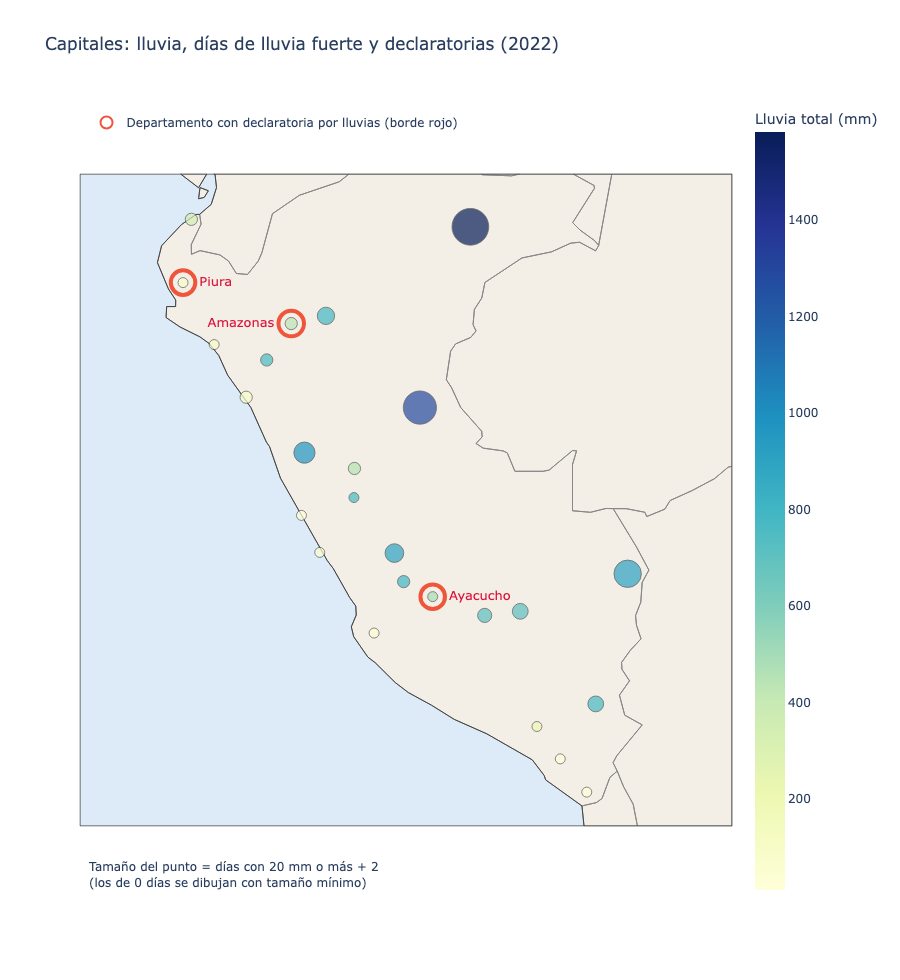

In [2]:
import plotly.graph_objects as go

mapa = pd.read_csv("datos/tabla_final.csv", encoding="utf-8-sig", dtype={"ubigeo": str})
mapa["tamano"] = mapa["dias_lluvia_fuerte"] + 2      # mínimo 2: los de 0 días de lluvia fuerte siguen viéndose

fig_mapa = px.scatter_geo(
    mapa, lat="latitud", lon="longitud", color="lluvia_total_mm", size="tamano", size_max=26,
    color_continuous_scale="YlGnBu", hover_name="departamento",
    hover_data={"capital": True, "lluvia_total_mm": ":.1f", "dias_lluvia_fuerte": True, "declaratorias": True,
                "tamano": False, "latitud": False, "longitud": False},
    title="Capitales: lluvia, días de lluvia fuerte y declaratorias (2022)",
    labels={"lluvia_total_mm": "Lluvia total (mm)", "dias_lluvia_fuerte": "Días con 20 mm o más",
            "declaratorias": "Declaratorias por lluvias", "capital": "Capital"},
)
fig_mapa.update_traces(marker={"line": {"width": 0.8, "color": "#333333"}})

# Los 3 departamentos con declaratoria: círculo más grande, vacío y con borde rojo grueso, con su nombre. Misma escala de tamaño que los puntos.
con_decl = mapa[mapa["declaratorias"] > 0]
base = fig_mapa.data[0].marker
fig_mapa.add_trace(go.Scattergeo(
    lat=con_decl["latitud"], lon=con_decl["longitud"], mode="markers+text", text=con_decl["departamento"],
    textposition=["middle left" if d == "Amazonas" else "middle right" for d in con_decl["departamento"]],
    textfont={"color": "crimson", "size": 13},
    marker={"symbol": "circle-open", "size": con_decl["tamano"] + 10, "sizemode": base.sizemode, "sizeref": base.sizeref,
            "opacity": 1, "line": {"width": 4, "color": "crimson"}},
    name="Departamento con declaratoria por lluvias (borde rojo)", hoverinfo="skip", showlegend=True))

fig_mapa.update_geos(fitbounds="locations", projection_type="mercator", showcountries=True, countrycolor="#888888",
                     showland=True, landcolor="#f3efe6", showocean=True, oceancolor="#dcebf7", showlakes=False)
fig_mapa.add_annotation(xref="paper", yref="paper", x=0.01, y=0.01, showarrow=False, align="left",
                        text="Tamaño del punto = días con 20 mm o más + 2<br>(los de 0 días se dibujan con tamaño mínimo)",
                        font={"size": 12})
fig_mapa.update_layout(width=900, height=980, legend={"x": 0.01, "y": 0.99, "bgcolor": "rgba(255,255,255,0.85)"})
fig_mapa.show()

In [3]:
# Cifras del mapa tomadas de la tabla (para describirlo con datos reales)
resumen_mapa = mapa.sort_values("lluvia_total_mm", ascending=False)[["departamento", "capital", "latitud", "longitud", "lluvia_total_mm", "dias_lluvia_fuerte", "declaratorias"]]
print("Las 6 capitales con más lluvia:")
print(resumen_mapa.head(6).to_string(index=False))
print()
print("Las 6 capitales con menos lluvia:")
print(resumen_mapa.tail(6).to_string(index=False))
print()
print("Capitales con 0 días de lluvia fuerte:", int((mapa["dias_lluvia_fuerte"] == 0).sum()), "de", len(mapa))
print("Con declaratoria (borde rojo):", mapa[mapa["declaratorias"] > 0]["departamento"].tolist())

Las 6 capitales con más lluvia:
 departamento          capital   latitud  longitud  lluvia_total_mm  dias_lluvia_fuerte  declaratorias
       Loreto          Iquitos  -3.74814 -73.25290           1581.8                  25              0
      Ucayali         Pucallpa  -8.37915 -74.55387           1288.8                  20              0
       Áncash           Huaraz  -9.52614 -77.52869            975.3                   7              0
        Junín         Huancayo -12.06866 -75.21027            910.4                   5              0
Madre de Dios Puerto Maldonado -12.58946 -69.19948            908.0                  13              0
 Huancavelica     Huancavelica -12.78691 -74.97298            803.8                   1              0

Las 6 capitales con menos lluvia:
departamento  capital   latitud  longitud  lluvia_total_mm  dias_lluvia_fuerte  declaratorias
       Piura    Piura  -5.18192 -80.65715             89.2                   0              1
      Callao   Callao -1

**Qué muestra el mapa** (solo patrones que se ven en la tabla; cifras de la celda de arriba)

- **Los tres círculos más grandes y oscuros son Loreto (Iquitos), Ucayali (Pucallpa) y Madre de Dios (Puerto Maldonado):** 1 581.8 mm y 25 días con 20 mm o más; 1 288.8 mm y 20 días; y 908.0 mm y 13 días. Por su latitud y longitud quedan en el noreste, el centro-este y el sureste del país. Áncash (975.3 mm) y Junín (910.4 mm) también tienen colores oscuros, pero con círculos pequeños (7 y 5 días).
- **Las capitales con menos lluvia son puntos claros y pequeños:** Tacna (11.5 mm), Lima-Huacho (13.9 mm), Moquegua (17.8 mm), Ica (25.1 mm), Callao (39.2 mm) y Piura (89.2 mm), y los cinco primeros quedan pegados a la costa del Pacífico en el mapa. **10 de las 25 capitales** tienen 0 días con 20 mm o más.
- **Los tres departamentos con declaratoria (borde rojo) son Amazonas (436.5 mm, 1 día), Ayacucho (485.1 mm, 0 días) y Piura (89.2 mm, 0 días).** En el mapa tienen colores claros o intermedios y tamaño mínimo o casi mínimo: ninguno está entre los puntos más oscuros ni más grandes.

**Qué NO muestra el mapa**

1. **Es una capital por departamento, no el territorio completo.** El punto es la capital (o, más exactamente, la celda de la cuadrícula del modelo más cercana) y el mapa no dibuja los límites de los departamentos, solo las fronteras entre países, así que no se ve qué parte de cada departamento llovió ni cuál fue la zona afectada. En Lima el punto es Huacho.
2. **Solo hay tres bordes rojos porque hay una sola norma de lluvias** (DS 032-2022-PCM) de las 29 que devolvió la búsqueda. Un departamento sin borde rojo no quiere decir que no tuvo emergencia, solo que no aparece en esa norma.
3. **No se puede inferir causalidad ni una relación.** Con tres puntos con declaratoria, el mapa describe cómo se reparten la lluvia y las declaratorias en estos datos; no explica por qué se declaró o no se declaró en cada lugar.
4. **Pucallpa incluye el día atípico** de 128.8 mm del 2022-04-01 (sin él tendría 1 160.0 mm y 19 días fuertes en lugar de 20); su color y su tamaño dependen de ese valor.
5. **El tamaño no es proporcional a los días:** es "días con 20 mm o más + 2", para que los de 0 días se vean. El valor real se lee al pasar el cursor (hover).

**Cosas del mapa que no quedan perfectas:** los límites son los de los países (sin departamentos), la escala de color de las capitales de poca lluvia es muy clara sobre el fondo beige, y la imagen PNG no tiene hover; por eso solo los tres departamentos con declaratoria llevan el nombre escrito.

## Mapa de calor de lluvia (grilla de puntos)

Hasta aquí el mapa tiene un punto por departamento (su capital). Aquí pedimos la lluvia de la temporada para una **grilla regular de puntos cada 0,5° de latitud y longitud** (unos 55 km) que cubre todo el territorio del Perú, y la dibujamos como un mapa de calor: cada departamento se pinta entero según la lluvia media de los puntos de la grilla que caen dentro de él, con los contornos rojos de los tres departamentos con declaratoria.

### Fuente de los contornos
Los contornos salen de `geo/peru_departamental.geojson`, descargado el 2026-10-04 de https://raw.githubusercontent.com/juaneladio/peru-geojson/master/peru_departamental_simple.geojson. **Es un repositorio de terceros (`juaneladio/peru-geojson`), no del INEI**, y **no verifiqué su licencia**. Es una versión *simplificada* (`_simple`): los límites son aproximados y no sirven para medir áreas ni para decidir a qué departamento pertenece un punto cercano a un límite. Cada departamento trae un código `FIRST_IDDP` de 2 dígitos que usamos como ubigeo.

In [4]:
import json
import numpy as np

with open("geo/peru_departamental.geojson", encoding="utf-8") as f:
    geojson = json.load(f)

tabla_final = pd.read_csv("datos/tabla_final.csv", encoding="utf-8-sig", dtype={"ubigeo": str})
ids_geojson = [feat["properties"]["FIRST_IDDP"] for feat in geojson["features"]]

print("Features del GeoJSON:", len(geojson["features"]))
print("FIRST_IDDP: todos texto de 2 dígitos:", all(isinstance(i, str) and len(i) == 2 for i in ids_geojson), "| únicos:", len(set(ids_geojson)))
print("Coinciden exactamente con los 25 ubigeos de tabla_final.csv:", set(ids_geojson) == set(tabla_final["ubigeo"]))
print("Tipos de geometría:", sorted({feat["geometry"]["type"] for feat in geojson["features"]}))

Features del GeoJSON: 25
FIRST_IDDP: todos texto de 2 dígitos: True | únicos: 25
Coinciden exactamente con los 25 ubigeos de tabla_final.csv: True
Tipos de geometría: ['MultiPolygon', 'Polygon']


### Grilla de puntos y punto en polígono

Generamos los puntos en múltiplos de 0,5° que caen dentro del rectángulo que envuelve al Perú y nos quedamos solo con los que caen **dentro de algún departamento**. Para saber si un punto está dentro de un polígono usamos el método clásico del **rayo**: se traza una línea horizontal desde el punto y se cuentan los lados del polígono que cruza; si es impar, el punto está dentro (los huecos del polígono se descuentan). Lo escribimos con `numpy` en lugar de instalar otra librería. Como comprobación, las **25 capitales** de la tabla final deben caer dentro del polígono de su propio departamento.

In [5]:
def en_anillo(x, y, anillo):
    """Método del rayo: para cada punto (x, y), ¿está dentro del anillo (lista de [lon, lat])?"""
    a = np.asarray(anillo)
    x1, y1, x2, y2 = a[:-1, 0][:, None], a[:-1, 1][:, None], a[1:, 0][:, None], a[1:, 1][:, None]
    cruza_en_y = (y1 > y[None, :]) != (y2 > y[None, :])
    with np.errstate(divide="ignore", invalid="ignore"):
        x_corte = x1 + (y[None, :] - y1) * (x2 - x1) / (y2 - y1)
    return ((cruza_en_y & (x[None, :] < x_corte)).sum(axis=0) % 2) == 1


def en_departamento(x, y, geometria):
    """Dentro de un Polygon o MultiPolygon (anillo exterior menos huecos)."""
    poligonos = [geometria["coordinates"]] if geometria["type"] == "Polygon" else geometria["coordinates"]
    dentro = np.zeros(len(x), dtype=bool)
    for anillos in poligonos:
        d = en_anillo(x, y, anillos[0])
        for hueco in anillos[1:]:
            d &= ~en_anillo(x, y, hueco)
        dentro |= d
    return dentro


# Comprobación con las 25 capitales: cada una debe caer dentro de su propio departamento
por_id = {feat["properties"]["FIRST_IDDP"]: feat for feat in geojson["features"]}
capital_dentro = {}
for _, f in tabla_final.iterrows():
    capital_dentro[f["departamento"]] = bool(en_departamento(np.array([f["longitud"]]), np.array([f["latitud"]]), por_id[f["ubigeo"]]["geometry"])[0])
print("Capitales que caen dentro del polígono de su departamento:", sum(capital_dentro.values()), "de", len(capital_dentro))
print("Las que NO:", [d for d, ok in capital_dentro.items() if not ok])

Capitales que caen dentro del polígono de su departamento: 25 de 25
Las que NO: []


In [6]:
PASO = 0.5

# Rectángulo que envuelve al Perú, en múltiplos exactos de 0,5°
todas = [pt for feat in geojson["features"]
         for poligono in ([feat["geometry"]["coordinates"]] if feat["geometry"]["type"] == "Polygon" else feat["geometry"]["coordinates"])
         for pt in poligono[0]]
lons, lats = np.array([p[0] for p in todas]), np.array([p[1] for p in todas])
print(f"Extensión del Perú en el GeoJSON: latitud {lats.min():.2f} a {lats.max():.2f}, longitud {lons.min():.2f} a {lons.max():.2f}")

lat_vals = np.arange(np.floor(lats.min() / PASO) * PASO, np.ceil(lats.max() / PASO) * PASO + PASO / 2, PASO)
lon_vals = np.arange(np.floor(lons.min() / PASO) * PASO, np.ceil(lons.max() / PASO) * PASO + PASO / 2, PASO)
LON, LAT = np.meshgrid(lon_vals, lat_vals)
candidatos = pd.DataFrame({"latitud": LAT.ravel(), "longitud": LON.ravel()})
print("Puntos de la grilla en el rectángulo:", len(candidatos))

# Cada punto pertenece como mucho a un departamento
candidatos["ubigeo"] = None
for ubigeo, feat in por_id.items():
    dentro = en_departamento(candidatos["longitud"].to_numpy(), candidatos["latitud"].to_numpy(), feat["geometry"])
    candidatos.loc[dentro & candidatos["ubigeo"].isna(), "ubigeo"] = ubigeo

grilla = candidatos.dropna(subset=["ubigeo"]).reset_index(drop=True)
grilla = grilla.merge(tabla_final[["ubigeo", "departamento"]], on="ubigeo", how="left")

print()
print("PUNTOS QUE CAEN DENTRO DE PERÚ:", len(grilla), "(esperado: entre 300 y 500)")
conteo = grilla["departamento"].value_counts().reindex(tabla_final["departamento"]).fillna(0).astype(int)
print("Departamentos sin ningún punto de la grilla:", conteo[conteo == 0].index.tolist())
print("Puntos por departamento (de más a menos):")
print(conteo.sort_values(ascending=False).to_string())

Extensión del Perú en el GeoJSON: latitud -18.35 a -0.04, longitud -81.33 a -68.65
Puntos de la grilla en el rectángulo: 1026

PUNTOS QUE CAEN DENTRO DE PERÚ: 428 (esperado: entre 300 y 500)
Departamentos sin ningún punto de la grilla: ['Callao']
Puntos por departamento (de más a menos):
departamento
Loreto           124
Ucayali           35
Madre de Dios     31
Puno              25
Arequipa          22
Cusco             22
San Martín        17
Junín             16
Ayacucho          14
Amazonas          13
Áncash            12
Piura             12
Huánuco           11
Lima              11
Cajamarca         11
Pasco              9
Apurímac           8
Huancavelica       7
La Libertad        7
Ica                6
Moquegua           5
Tacna              5
Lambayeque         4
Tumbes             1
Callao             0


### La grilla: 428 puntos dentro de Perú

La grilla cubre el rectángulo del Perú con 1 026 puntos y **428 caen dentro de algún departamento**, entre los 300 y 500 esperados. Las 25 capitales caen dentro del polígono de su departamento, lo que confirma que el método del rayo y el GeoJSON funcionan. Loreto, que es el departamento más grande, aporta 124 puntos; **el Callao no recibe ningún punto** (su polígono es muy pequeño frente a una grilla de 0,5°) y Tumbes solo uno. En el mapa por departamentos, el Callao se pinta con la lluvia de su capital (marcado aparte) y Tumbes con la media de su único punto.

## Consulta a la API histórica de Open-Meteo

Según la documentación de la API histórica (`archive-api.open-meteo.com`):

- **Varias coordenadas en una consulta:** se separan con comas, por ejemplo `latitude=52.52,48.85&longitude=13.41,2.35`. Con varias ubicaciones, el JSON de respuesta es **una lista de estructuras**, una por ubicación y en el mismo orden.
- **Altitud:** cada respuesta trae `elevation`, la elevación de un modelo digital de 90 m para esa coordenada (con ella la API elige la celda de su cuadrícula y ajusta el clima a esa altura). Es la "altitud que devuelve la API".
- **Máximo de coordenadas por consulta:** la documentación **no indica un máximo**. Usamos 20 puntos por consulta.
- **Límites de uso gratuito** (página de precios): 600 llamadas por minuto, 5 000 por hora y 10 000 por día. Una consulta de más de 2 semanas para una ubicación **cuenta como varias llamadas** (aproximadamente días / 14), así que 151 días pesan cerca de **10.8 llamadas por punto** y los 428 puntos unas **4 600 llamadas**, el 92 % de la cuota horaria. Esto es una estimación mía a partir de la documentación, no un dato que devuelva la API.

Por eso **no hacemos solo 1 segundo de pausa**: una consulta de 20 puntos pesa unas 216 llamadas, y con 30 segundos de pausa quedamos en unas 430 por minuto, por debajo del tope de 600. Son unas 22 consultas y unos 11 minutos. **Si la API contesta con un error 429 o de límite, el código se detiene y no insiste.**

Cada respuesta se guarda en `geo/_respuestas_api_lluvia_2022.json` apenas llega. Si el notebook se vuelve a ejecutar, **reutiliza ese archivo** y no vuelve a gastar cuota de la API (se puede borrar si se quiere volver a pedir todo).

In [7]:
import time
import requests
import os

URL_ARCHIVO = "https://archive-api.open-meteo.com/v1/archive"
INICIO, FIN = "2022-01-01", "2022-05-31"
TAMANO_LOTE = 20          # puntos por consulta
PAUSA_S = 30              # segundos entre consultas (>= 1 s; 30 s para respetar el tope de 600 llamadas por minuto)
RUTA_CACHE = "geo/_respuestas_api_lluvia_2022.json"

puntos = grilla[["latitud", "longitud"]].round(2)
lotes = [puntos.iloc[i:i + TAMANO_LOTE] for i in range(0, len(puntos), TAMANO_LOTE)]

cache = json.load(open(RUTA_CACHE, encoding="utf-8")) if os.path.exists(RUTA_CACHE) else {}
respuestas = []        # un diccionario por punto, en el orden de la grilla
consultas_reales = consultas_cache = 0
detenido = None

for n, lote in enumerate(lotes):
    clave = f"{n}|" + ",".join(f"{a:.2f}/{b:.2f}" for a, b in zip(lote["latitud"], lote["longitud"]))
    if clave in cache:                                   # ya pedido antes: no gastamos cuota
        respuestas.extend(cache[clave]); consultas_cache += 1
        continue
    r = requests.get(URL_ARCHIVO, timeout=180, params={
        "latitude": ",".join(f"{v:.2f}" for v in lote["latitud"]),
        "longitude": ",".join(f"{v:.2f}" for v in lote["longitud"]),
        "start_date": INICIO, "end_date": FIN,
        "daily": "precipitation_sum", "timezone": "America/Lima"})
    consultas_reales += 1
    if r.status_code != 200:                             # 429 u otro error: nos detenemos, sin reintentar
        detenido = (n + 1, r.status_code, r.text[:300])
        break
    datos = r.json()
    datos = datos if isinstance(datos, list) else [datos]
    if len(datos) != len(lote):
        detenido = (n + 1, "respuesta con otra cantidad de puntos", f"{len(datos)} en vez de {len(lote)}")
        break
    reducidas = [{"elevation": d["elevation"], "lat_api": d["latitude"], "lon_api": d["longitude"],
                  "fechas": d["daily"]["time"], "lluvia": d["daily"]["precipitation_sum"],
                  "unidad": d["daily_units"]["precipitation_sum"]} for d in datos]
    cache[clave] = reducidas
    json.dump(cache, open(RUTA_CACHE, "w", encoding="utf-8"))   # guardamos apenas llega
    respuestas.extend(reducidas)
    if n < len(lotes) - 1:
        time.sleep(PAUSA_S)

print("Consultas totales:", len(lotes), "| hechas a la API ahora:", consultas_reales, "| leídas del archivo de caché:", consultas_cache)
print("Puntos con respuesta:", len(respuestas), "de", len(puntos))
if detenido:
    print()
    print("DETENIDO en la consulta", detenido[0], "de", len(lotes), "| código:", detenido[1])
    print("Respuesta de la API:", detenido[2])
    raise RuntimeError("La API respondió con un error o un límite: se detiene aquí, sin insistir.")

Consultas totales: 22 | hechas a la API ahora: 0 | leídas del archivo de caché: 22
Puntos con respuesta: 428 de 428


**Cómo fue la consulta real.** En la primera ejecución del notebook se hicieron **22 consultas a la API** (20 puntos cada una, salvo la última), con **30 segundos de pausa** entre ellas (unos 11 minutos en total), y **todas respondieron bien**: ningún error 429 ni de límite. Con la estimación de peso de la documentación (aprox. 10.8 llamadas por punto con 151 días), la corrida pesó unas 4 600 llamadas de las 5 000 por hora de la cuota gratuita; es una estimación mía, no una cifra que devuelva la API.

Cada respuesta se guardó apenas llegó en `geo/_respuestas_api_lluvia_2022.json` (1.3 MB). **Las ejecuciones siguientes leen ese archivo y no vuelven a pedir nada a la API**, por eso la celda de arriba dice "hechas a la API ahora: 0 | leídas del archivo de caché: 22". Si se borra el archivo, el notebook volvería a pedir todo.

## Verificación de la respuesta: 151 días por punto y días sin dato

Del 2022-01-01 al 2022-05-31 hay **151 días**. Comprobamos para cada punto: cuántos días devolvió, que la primera y la última fecha sean las pedidas, que las fechas no se repitan, que la unidad sea mm, y cuántos valores vienen como `None` (sin dato).

In [8]:
ver = pd.DataFrame({
    "dias": [len(r["fechas"]) for r in respuestas],
    "valores": [len(r["lluvia"]) for r in respuestas],
    "primera": [r["fechas"][0] for r in respuestas],
    "ultima": [r["fechas"][-1] for r in respuestas],
    "repetidas": [len(r["fechas"]) - len(set(r["fechas"])) for r in respuestas],
    "sin_dato": [sum(1 for x in r["lluvia"] if x is None) for r in respuestas],
    "unidad": [r["unidad"] for r in respuestas],
})
print("Puntos con 151 días:", int((ver["dias"] == 151).sum()), "de", len(ver), "| con 151 valores de lluvia:", int((ver["valores"] == 151).sum()))
print("Primera fecha distinta de", INICIO, ":", int((ver["primera"] != INICIO).sum()), "| última fecha distinta de", FIN, ":", int((ver["ultima"] != FIN).sum()))
print("Fechas repetidas:", int(ver["repetidas"].sum()), "| unidades:", ver["unidad"].unique().tolist())
print()
print("DÍAS SIN DATO (None) EN TOTAL:", int(ver["sin_dato"].sum()), "de", int(ver["valores"].sum()), "valores")
print("Puntos con al menos un día sin dato:", int((ver["sin_dato"] > 0).sum()))
print("Valores negativos:", sum(1 for r in respuestas for x in r["lluvia"] if x is not None and x < 0))
print("Valores que no son números (y no son None):", sum(1 for r in respuestas for x in r["lluvia"] if x is not None and not isinstance(x, (int, float))))

Puntos con 151 días: 428 de 428 | con 151 valores de lluvia: 428
Primera fecha distinta de 2022-01-01 : 0 | última fecha distinta de 2022-05-31 : 0
Fechas repetidas: 0 | unidades: ['mm']

DÍAS SIN DATO (None) EN TOTAL: 0 de 64628 valores
Puntos con al menos un día sin dato: 0
Valores negativos: 0
Valores que no son números (y no son None): 0


**Días sin dato.** Los 428 puntos devolvieron **151 días** cada uno (64 628 valores en total = 428 × 151), con la primera fecha el 2022-01-01 y la última el 2022-05-31, sin fechas repetidas, en mm, y **0 valores `None`**: no hubo días sin dato en ningún punto, así que **no hubo que excluir, rellenar ni interpolar nada**. El 0 es el resultado de haberlo comprobado. Por si apareciera algún `None` en otra corrida, la suma los ignora y el conteo de días de lluvia fuerte no los cuenta (un día sin dato no es un día de 0 mm).

## Lluvia total, días de lluvia fuerte y altitud por punto

- `lluvia_total_mm`: la suma de la lluvia diaria de la temporada (los `None`, si los hubiera, no se suman).
- `dias_lluvia_fuerte`: días con **20 mm o más**.
- `altitud_m`: el campo `elevation` que devuelve la API.

Guardamos el resultado en `geo/lluvia_grilla_2022.csv` (no en `datos/`), con `index=False` y `encoding="utf-8-sig"`, con el ubigeo como texto de 2 dígitos.

In [9]:
grilla_lluvia = grilla.copy()
grilla_lluvia["altitud_m"] = [r["elevation"] for r in respuestas]
grilla_lluvia["lluvia_total_mm"] = [round(sum(x for x in r["lluvia"] if x is not None), 1) for r in respuestas]
grilla_lluvia["dias_lluvia_fuerte"] = [sum(1 for x in r["lluvia"] if x is not None and x >= 20) for r in respuestas]
grilla_lluvia["max_dia_mm"] = [max(x for x in r["lluvia"] if x is not None) for r in respuestas]
grilla_lluvia["lat_api"] = [r["lat_api"] for r in respuestas]
grilla_lluvia["lon_api"] = [r["lon_api"] for r in respuestas]

columnas = ["ubigeo", "departamento", "latitud", "longitud", "altitud_m", "lluvia_total_mm", "dias_lluvia_fuerte"]
grilla_lluvia[columnas].to_csv("geo/lluvia_grilla_2022.csv", index=False, encoding="utf-8-sig")

leida = pd.read_csv("geo/lluvia_grilla_2022.csv", encoding="utf-8-sig", dtype={"ubigeo": str})
print("Archivo geo/lluvia_grilla_2022.csv:", leida.shape, "| columnas:", leida.columns.tolist())
print("Ubigeos de 2 dígitos:", bool(leida["ubigeo"].str.fullmatch(r"\d{2}").all()), "| valores vacíos:", int(leida.isna().sum().sum()))
print()
print(grilla_lluvia[["lluvia_total_mm", "dias_lluvia_fuerte", "altitud_m", "max_dia_mm"]].describe().round(1).to_string())
print()
print("Los 8 puntos con más lluvia:")
print(grilla_lluvia.sort_values("lluvia_total_mm", ascending=False).head(8)[["departamento", "latitud", "longitud", "altitud_m", "lluvia_total_mm", "dias_lluvia_fuerte", "max_dia_mm"]].to_string(index=False))
print()
print("Los 5 puntos con menos lluvia:")
print(grilla_lluvia.sort_values("lluvia_total_mm").head(5)[["departamento", "latitud", "longitud", "altitud_m", "lluvia_total_mm", "dias_lluvia_fuerte"]].to_string(index=False))

Archivo geo/lluvia_grilla_2022.csv: (428, 7) | columnas: ['ubigeo', 'departamento', 'latitud', 'longitud', 'altitud_m', 'lluvia_total_mm', 'dias_lluvia_fuerte']
Ubigeos de 2 dígitos: True | valores vacíos: 0

       lluvia_total_mm  dias_lluvia_fuerte  altitud_m  max_dia_mm
count            428.0               428.0      428.0       428.0
mean            1107.5                14.8     1479.9        43.7
std              553.0                12.3     1633.0        24.7
min                7.9                 0.0       19.0         1.6
25%              720.3                 2.0      192.5        25.4
50%             1149.9                14.0      466.5        42.5
75%             1571.7                25.0     2894.5        56.1
max             2697.3                56.0     5100.0       215.4

Los 8 puntos con más lluvia:
 departamento  latitud  longitud  altitud_m  lluvia_total_mm  dias_lluvia_fuerte  max_dia_mm
     Amazonas     -6.0     -78.5     1697.0           2697.3              

## Mapa de calor de lluvia: cada departamento pintado entero

En lugar de dibujar la grilla como cuadrados, **pintamos cada departamento entero** según la **lluvia media de los puntos de la grilla que caen dentro de él**, calculada desde `geo/lluvia_grilla_2022.csv` (la media de `lluvia_total_mm` de sus puntos). Usamos los polígonos de `geo/peru_departamental.geojson` con `go.Choropleth` (sin tokens ni teselas externas, así que se exporta bien a PNG). Encima, **contorno rojo grueso** en Amazonas, Ayacucho y Piura, los tres departamentos con declaratoria por lluvias.

**El Callao no tiene puntos en la grilla** (su polígono es muy pequeño frente a una grilla de 0,5°). Para no dejarlo sin color usamos **la lluvia de su capital** (la de `tabla_final.csv`), y lo **marcamos con un rombo negro y su nombre** y una entrada en la leyenda, porque es un valor de otra clase: una sola ciudad, no una media de puntos.

No se hace ninguna consulta nueva a la API: todo sale de los archivos que ya existen.

Departamentos con declaratoria (contorno rojo): ['Amazonas', 'Ayacucho', 'Piura']
Departamentos sin ningún punto en la grilla: ['Callao']
Departamentos pintados: 25 | con media de la grilla: 24 | con la lluvia de su capital: 1

     departamento  puntos  lluvia_en_el_mapa_mm  lluvia_de_la_capital_mm                                          origen  declaratorias
0          Loreto     124                1637.0                   1581.8                media de los puntos de la grilla              0
1        Amazonas      13                1413.8                    436.5                media de los puntos de la grilla              1
2      San Martín      17                1276.3                    789.8                media de los puntos de la grilla              0
3         Ucayali      35                1273.7                   1288.8                media de los puntos de la grilla              0
4           Pasco       9                1176.1                    774.0                medi

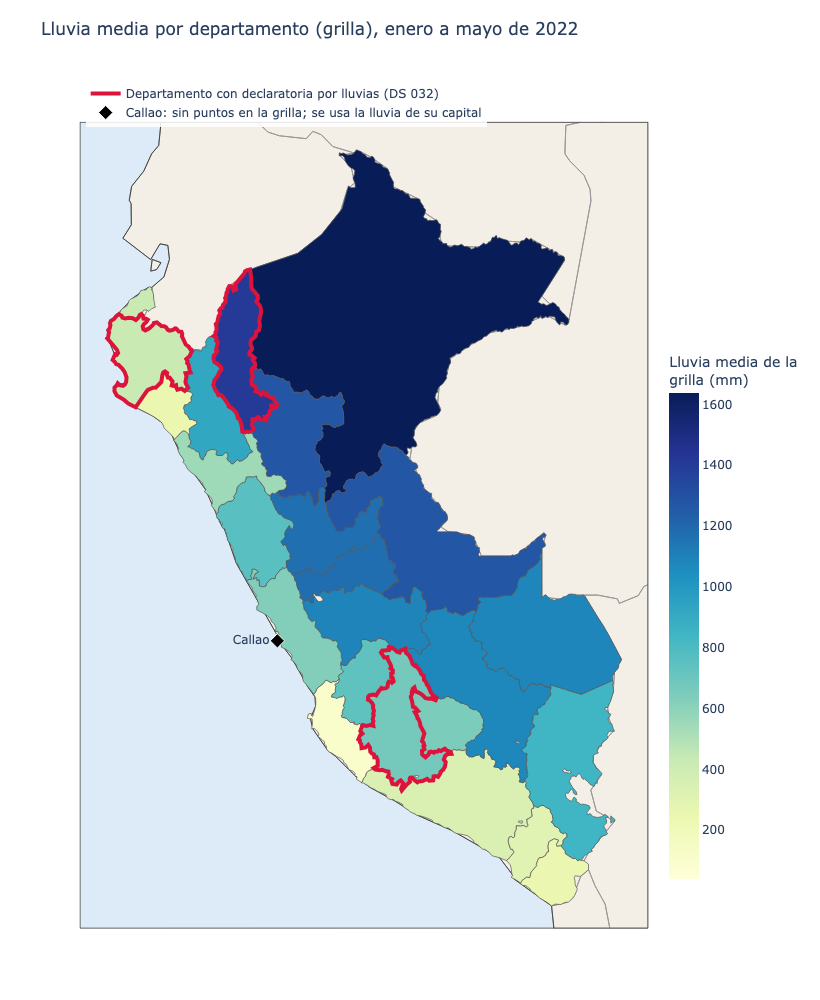

In [10]:
import plotly.graph_objects as go
import plotly.io as pio

pio.renderers.default = "plotly_mimetype+png"

# Departamentos con declaratoria por lluvias (de la tabla final) y función para sacar los contornos de un departamento
declarados = tabla_final.loc[tabla_final["declaratorias"] > 0, "ubigeo"].tolist()
print("Departamentos con declaratoria (contorno rojo):", tabla_final.loc[tabla_final["declaratorias"] > 0, "departamento"].tolist())


def lineas_de(feat):
    """Lista de (lons, lats) con los anillos exteriores de un Polygon/MultiPolygon."""
    g = feat["geometry"]
    poligonos = [g["coordinates"]] if g["type"] == "Polygon" else g["coordinates"]
    return [([p[0] for p in pol[0]], [p[1] for p in pol[0]]) for pol in poligonos]


# Lluvia media de la grilla por departamento, leída desde el archivo guardado (no se toca la API)
puntos_grilla = pd.read_csv("geo/lluvia_grilla_2022.csv", encoding="utf-8-sig", dtype={"ubigeo": str})
medias = (puntos_grilla.groupby("ubigeo").agg(puntos=("lluvia_total_mm", "size"), lluvia_media_mm=("lluvia_total_mm", "mean"))
          .round(1).reset_index())

mapa_dep = tabla_final[["ubigeo", "departamento", "capital", "latitud", "longitud", "lluvia_total_mm", "declaratorias"]].merge(medias, on="ubigeo", how="left")
sin_puntos = mapa_dep["puntos"].isna()
print("Departamentos sin ningún punto en la grilla:", mapa_dep.loc[sin_puntos, "departamento"].tolist())

# Callao (sin puntos): se usa la lluvia de su capital y se marca
mapa_dep["lluvia_mapa_mm"] = mapa_dep["lluvia_media_mm"].where(~sin_puntos, mapa_dep["lluvia_total_mm"])
mapa_dep["puntos"] = mapa_dep["puntos"].fillna(0).astype(int)
mapa_dep["origen"] = ["lluvia de su capital (sin puntos en la grilla)" if s else "media de los puntos de la grilla" for s in sin_puntos]
print("Departamentos pintados:", len(mapa_dep), "| con media de la grilla:", int((~sin_puntos).sum()), "| con la lluvia de su capital:", int(sin_puntos.sum()))
print()
print(mapa_dep.sort_values("lluvia_mapa_mm", ascending=False)[["departamento", "puntos", "lluvia_mapa_mm", "lluvia_total_mm", "origen", "declaratorias"]]
      .rename(columns={"lluvia_mapa_mm": "lluvia_en_el_mapa_mm", "lluvia_total_mm": "lluvia_de_la_capital_mm"}).reset_index(drop=True).to_string())

texto = [f"{f['departamento']}<br>Lluvia en el mapa: {f['lluvia_mapa_mm']:.1f} mm<br>({f['origen']}"
         + (f"; {f['puntos']} puntos)" if f["puntos"] else ")")
         + f"<br>Lluvia de su capital ({f['capital']}): {f['lluvia_total_mm']:.1f} mm<br>Declaratorias por lluvias: {f['declaratorias']}"
         for _, f in mapa_dep.iterrows()]

fig_dep = go.Figure(go.Choropleth(
    geojson=geojson, locations=mapa_dep["ubigeo"], featureidkey="properties.FIRST_IDDP", z=mapa_dep["lluvia_mapa_mm"],
    colorscale="YlGnBu", marker_line_color="#555555", marker_line_width=0.7, hovertext=texto, hoverinfo="text",
    colorbar={"title": {"text": "Lluvia media de la<br>grilla (mm)"}, "len": 0.6, "y": 0.4}, name="Lluvia"))

# Contorno rojo grueso en los departamentos con declaratoria por lluvias
primero = True
for feat in geojson["features"]:
    if feat["properties"]["FIRST_IDDP"] in declarados:
        for lons, lats in lineas_de(feat):
            fig_dep.add_trace(go.Scattergeo(lon=lons, lat=lats, mode="lines", hoverinfo="skip", line={"width": 4, "color": "crimson"},
                                            name="Departamento con declaratoria por lluvias (DS 032)", showlegend=primero))
            primero = False

# Marca del Callao: su valor es el de su capital, no una media de la grilla
cal = mapa_dep[sin_puntos]
fig_dep.add_trace(go.Scattergeo(lon=cal["longitud"], lat=cal["latitud"], mode="markers+text", text=cal["departamento"], textposition="middle left",
                                marker={"symbol": "diamond", "size": 11, "color": "black", "line": {"width": 1, "color": "white"}},
                                name="Callao: sin puntos en la grilla; se usa la lluvia de su capital", hoverinfo="skip"))

fig_dep.update_geos(lonaxis_range=[-82, -68], lataxis_range=[-19, 0.5], projection_type="mercator",
                    showcountries=True, countrycolor="#999999", showland=True, landcolor="#f3efe6",
                    showocean=True, oceancolor="#dcebf7", showlakes=False, visible=True)
fig_dep.update_layout(title="Lluvia media por departamento (grilla), enero a mayo de 2022", width=820, height=1000,
                      legend={"x": 0.01, "y": 0.99, "bgcolor": "rgba(255,255,255,0.85)"}, margin={"t": 70, "b": 20})
fig_dep.show()

In [11]:
# ¿Cuánto pesa un solo punto en la media de un departamento? Amazonas sin su punto más lluvioso (solo lectura)
amz = puntos_grilla[puntos_grilla["ubigeo"] == "01"]
sin_max = amz.drop(amz["lluvia_total_mm"].idxmax())
print(f"Amazonas: {len(amz)} puntos, media {amz['lluvia_total_mm'].mean():.1f} mm | sin su punto más lluvioso ({amz['lluvia_total_mm'].max():.1f} mm): {len(sin_max)} puntos, media {sin_max['lluvia_total_mm'].mean():.1f} mm")
siguiente = mapa_dep[mapa_dep["departamento"] != "Amazonas"].sort_values("lluvia_mapa_mm", ascending=False).iloc[:2][["departamento", "lluvia_mapa_mm"]]
print("Departamentos que le siguen en el mapa:", siguiente.to_dict("records"))
# Amazonas es el 2.º si solo Loreto lo supera: su media debe seguir por encima de la del 3.º departamento (el 2.º de "los que le siguen")
print("¿Amazonas seguiría siendo el 2.º sin ese punto?", bool(sin_max["lluvia_total_mm"].mean() > siguiente["lluvia_mapa_mm"].iloc[1]))
print()
print("Puntos por departamento (de menos a más): las medias de los que tienen pocos puntos son menos firmes")
print(mapa_dep.sort_values("puntos")[["departamento", "puntos", "lluvia_mapa_mm"]].head(8).to_string(index=False))

Amazonas: 13 puntos, media 1413.8 mm | sin su punto más lluvioso (2697.3 mm): 12 puntos, media 1306.8 mm
Departamentos que le siguen en el mapa: [{'departamento': 'Loreto', 'lluvia_mapa_mm': 1637.0}, {'departamento': 'San Martín', 'lluvia_mapa_mm': 1276.3}]
¿Amazonas seguiría siendo el 2.º sin ese punto? True

Puntos por departamento (de menos a más): las medias de los que tienen pocos puntos son menos firmes
departamento  puntos  lluvia_mapa_mm
      Callao       0            39.2
      Tumbes       1           422.0
  Lambayeque       4           249.1
       Tacna       5           251.1
    Moquegua       5           307.4
         Ica       6           106.0
 La Libertad       7           551.4
Huancavelica       7           737.7


**Qué muestra el mapa** (solo patrones que se ven en la tabla de arriba y en la imagen)

- **Lo más lluvioso queda al norte y al este.** Loreto (124 puntos) tiene la lluvia media más alta, **1 637.0 mm**, y es el bloque oscuro del noreste. Le siguen Amazonas (**1 413.8 mm**, 13 puntos), San Martín (1 276.3 mm), Ucayali (1 273.7 mm), Pasco (1 176.1 mm) y Huánuco (1 171.3 mm).
- **Lo más seco queda en la costa del sur y del centro-norte:** Ica (**106.0 mm**, 6 puntos), Lambayeque (249.1 mm), Tacna (251.1 mm), Moquegua (307.4 mm) y Arequipa (339.1 mm). El **Callao (39.2 mm)** es aún más bajo, pero **no es comparable**: es la lluvia de su capital, no una media de puntos.
- **Los tres departamentos con contorno rojo:** Amazonas es el **2.º del mapa** (1 413.8 mm); Ayacucho es el **14.º** (**669.8 mm**) y Piura el **18.º** (**422.3 mm**) de 25. Con la sola capital (Parte 3) ocupaban los puestos 15.º, 13.º y 20.º: **Amazonas sube mucho al medir con la grilla, y Ayacucho y Piura casi no se mueven**.
- **La capital no siempre representa al departamento.** Lima tiene **628.3 mm** de media en la grilla (11 puntos) frente a **13.9 mm** en su capital, Huacho; La Libertad, 551.4 mm frente a 98.9 mm; Amazonas, 1 413.8 mm frente a 436.5 mm.

**Qué NO muestra el mapa**

1. **Pintar el departamento entero esconde lo que cambia dentro de él.** Cada color es una media de puntos. Por ejemplo, Piura promedia 422.3 mm pero tiene un punto de 1 701.0 mm. Además, las medias de los departamentos con pocos puntos son menos firmes: Tumbes tiene **1 punto**, Lambayeque 4, y Moquegua y Tacna 5 cada uno, frente a los 124 de Loreto.
2. **No sabemos en qué distritos aplica la DS 032-2022-PCM.** Su PDF no tiene texto extraíble (ver `innovacion_auditoria_fuente.ipynb`) y su título solo dice "algunos distritos de varias provincias" de Amazonas, Ayacucho y Piura. **El contorno rojo marca departamentos completos, no los distritos afectados.**
3. **El Callao está pintado con otra clase de dato** (su capital, marcado con el rombo negro), no con puntos de la grilla.
4. **La grilla es de modelo, no de estaciones**, y reparte los puntos por el territorio, no por la población: un departamento grande pesa más puntos que uno pequeño, pero eso no dice cuánta gente recibió esa lluvia.
5. **No hay causalidad.** El mapa no permite decir que la lluvia causó la declaratoria ni lo contrario; Amazonas tiene mucha lluvia en el mapa, mientras Ayacucho y Piura tienen lluvia moderada y baja, y los tres tienen declaratoria.
6. **Hay una sola norma de lluvias.** Los otros 22 departamentos no tienen declaratoria por lluvias **en nuestra búsqueda**; no quiere decir que no hubo emergencias.
7. **Límites del dibujo.** Los contornos son una versión simplificada de un repositorio de terceros; por eso, por ejemplo, el rombo del Callao (la capital) aparece algo dentro del mar en el mapa.

## Lluvia por franja de altitud

Agrupamos los 428 puntos según la `altitud_m` que devuelve la API: **menos de 500 m**, **de 500 a 2 500 m** (incluidos ambos extremos) y **más de 2 500 m**. Para cada franja: número de puntos, lluvia promedio y días de lluvia fuerte promedio.

In [12]:
alt = grilla_lluvia["altitud_m"]
grilla_lluvia["franja_altitud"] = np.select([alt < 500, alt <= 2500], ["menos de 500 m", "de 500 a 2 500 m"], default="más de 2 500 m")

por_franja = (grilla_lluvia.groupby("franja_altitud")
              .agg(puntos=("lluvia_total_mm", "size"), lluvia_promedio_mm=("lluvia_total_mm", "mean"),
                   dias_lluvia_fuerte_promedio=("dias_lluvia_fuerte", "mean"))
              .round(1).reindex(["menos de 500 m", "de 500 a 2 500 m", "más de 2 500 m"]))
print("Puntos en las tres franjas:", int(por_franja["puntos"].sum()), "de", len(grilla_lluvia))
print("Altitud mínima y máxima:", alt.min(), "y", alt.max(), "| puntos con altitud exactamente 500:", int((alt == 500).sum()), "| exactamente 2500:", int((alt == 2500).sum()))
por_franja

Puntos en las tres franjas: 428 de 428
Altitud mínima y máxima: 19.0 y 5100.0 | puntos con altitud exactamente 500: 0 | exactamente 2500: 0


,puntos,lluvia_promedio_mm,dias_lluvia_fuerte_promedio
franja_altitud,,,
menos de 500 m,218,1319.9,21.4
de 500 a 2 500 m,93,994.1,12.4
más de 2 500 m,117,801.7,4.4


In [13]:
# Para describir el mapa con datos reales: resumen por departamento (puntos de la grilla) frente a la capital
resumen_dep = (grilla_lluvia.groupby("departamento").agg(puntos=("lluvia_total_mm", "size"), lluvia_media_mm=("lluvia_total_mm", "mean"),
               lluvia_max_mm=("lluvia_total_mm", "max"), altitud_media_m=("altitud_m", "mean")).round(0)
               .merge(tabla_final[["departamento", "lluvia_total_mm", "declaratorias"]].rename(columns={"lluvia_total_mm": "lluvia_capital_mm"}), on="departamento"))
print("Departamentos de la DS 032 (grilla vs capital):")
print(resumen_dep[resumen_dep["declaratorias"] > 0].to_string(index=False))
print()
print("Los 6 departamentos con mayor lluvia media en la grilla:")
print(resumen_dep.sort_values("lluvia_media_mm", ascending=False).head(6).to_string(index=False))
print()
print("Los 6 con menor lluvia media en la grilla:")
print(resumen_dep.sort_values("lluvia_media_mm").head(6).to_string(index=False))
print()
print("Puntos de la grilla con un día de 100 mm o más:")
print(grilla_lluvia[grilla_lluvia["max_dia_mm"] >= 100][["departamento", "latitud", "longitud", "altitud_m", "lluvia_total_mm", "max_dia_mm"]].to_string(index=False))
print()
print("Lluvia en los 428 puntos: mediana", grilla_lluvia["lluvia_total_mm"].median(), "mm | en las 25 capitales: mediana", tabla_final["lluvia_total_mm"].median(), "mm")

Departamentos de la DS 032 (grilla vs capital):
departamento  puntos  lluvia_media_mm  lluvia_max_mm  altitud_media_m  lluvia_capital_mm  declaratorias
    Amazonas      13           1414.0         2697.0           1299.0              436.5              1
    Ayacucho      14            670.0         1186.0           3503.0              485.1              1
       Piura      12            422.0         1701.0            679.0               89.2              1

Los 6 departamentos con mayor lluvia media en la grilla:
departamento  puntos  lluvia_media_mm  lluvia_max_mm  altitud_media_m  lluvia_capital_mm  declaratorias
      Loreto     124           1637.0         2084.0            196.0             1581.8              0
    Amazonas      13           1414.0         2697.0           1299.0              436.5              1
  San Martín      17           1276.0         1860.0           1510.0              789.8              0
     Ucayali      35           1274.0         1652.0          

In [14]:
# Revisión de lo que se ve raro (solo lectura; no se corrige nada)
grilla_lluvia["fecha_max"] = [r["fechas"][r["lluvia"].index(max(x for x in r["lluvia"] if x is not None))] for r in respuestas]

print("¿En qué fecha cae el día más lluvioso de los puntos con un día de 100 mm o más?")
fuertes = grilla_lluvia[grilla_lluvia["max_dia_mm"] >= 100]
print(fuertes[["departamento", "latitud", "longitud", "max_dia_mm", "fecha_max"]].sort_values("max_dia_mm", ascending=False).to_string(index=False))
print("Fechas repetidas entre esos puntos:", fuertes["fecha_max"].value_counts().to_dict())
print()
print("En todos los 428 puntos, las 5 fechas que más veces son el día más lluvioso del punto:")
print(grilla_lluvia["fecha_max"].value_counts().head(5).to_string())
print()
print("El punto con más lluvia (celda oscura aislada en Amazonas):")
top = grilla_lluvia.sort_values("lluvia_total_mm", ascending=False).head(3)[["departamento", "latitud", "longitud", "altitud_m", "lluvia_total_mm", "dias_lluvia_fuerte"]]
print(top.to_string(index=False))
print("Diferencia entre el 1.º y el 2.º punto con más lluvia:", round(top["lluvia_total_mm"].iloc[0] - top["lluvia_total_mm"].iloc[1], 1), "mm")
vecinos = grilla_lluvia[(grilla_lluvia["latitud"].sub(-6.0).abs() <= 0.5) & (grilla_lluvia["longitud"].sub(-78.5).abs() <= 0.5) & ~((grilla_lluvia["latitud"] == -6.0) & (grilla_lluvia["longitud"] == -78.5))]
print("Puntos vecinos (a 0,5° o menos) de ese punto:")
print(vecinos[["departamento", "latitud", "longitud", "altitud_m", "lluvia_total_mm"]].to_string(index=False))

¿En qué fecha cae el día más lluvioso de los puntos con un día de 100 mm o más?
departamento  latitud  longitud  max_dia_mm  fecha_max
     Ucayali     -9.0     -74.0       215.4 2022-04-01
     Ucayali    -10.5     -73.5       175.5 2022-01-30
      Loreto     -3.5     -77.0       173.9 2022-03-21
     Ucayali     -9.0     -74.5       117.2 2022-02-20
     Ucayali     -8.5     -74.5       114.9 2022-04-01
     Huánuco     -9.5     -75.0       109.3 2022-01-30
     Ucayali    -11.0     -73.5       107.3 2022-01-30
     Ucayali     -9.0     -73.0       106.3 2022-02-21
     Ucayali     -9.0     -73.5       103.3 2022-03-20
       Junín    -11.0     -75.0       102.2 2022-03-13
Fechas repetidas entre esos puntos: {'2022-01-30': 3, '2022-04-01': 2, '2022-03-13': 1, '2022-02-20': 1, '2022-03-20': 1, '2022-02-21': 1, '2022-03-21': 1}

En todos los 428 puntos, las 5 fechas que más veces son el día más lluvioso del punto:
fecha_max
2022-04-01    33
2022-01-25    22
2022-01-30    19
2022-03-21

In [15]:
# Dentro de cada franja de altitud también miramos el mínimo y el máximo, para ver qué tan distintos son los puntos que agrupa
extra = grilla_lluvia.groupby("franja_altitud").agg(lluvia_min_mm=("lluvia_total_mm", "min"), lluvia_mediana_mm=("lluvia_total_mm", "median"),
                                                    lluvia_max_mm=("lluvia_total_mm", "max")).reindex(["menos de 500 m", "de 500 a 2 500 m", "más de 2 500 m"])
print(extra.round(1).to_string())
print()
bajos = grilla_lluvia[grilla_lluvia["altitud_m"] < 500]
print("Puntos de menos de 500 m con menos de 100 mm (franja seca):", int((bajos["lluvia_total_mm"] < 100).sum()), "| con más de 1 500 mm (franja húmeda):", int((bajos["lluvia_total_mm"] > 1500).sum()), "| de", len(bajos))
print("Departamentos de los puntos de menos de 500 m con menos de 100 mm:", sorted(bajos[bajos["lluvia_total_mm"] < 100]["departamento"].unique()))
print("Departamentos de los puntos de menos de 500 m con más de 1 500 mm:", sorted(bajos[bajos["lluvia_total_mm"] > 1500]["departamento"].unique()))

                  lluvia_min_mm  lluvia_mediana_mm  lluvia_max_mm
franja_altitud                                                   
menos de 500 m              7.9             1466.9         2083.5
de 500 a 2 500 m            9.3             1105.7         2697.3
más de 2 500 m            111.0              747.1         1880.3

Puntos de menos de 500 m con menos de 100 mm (franja seca): 16 | con más de 1 500 mm (franja húmeda): 103 | de 218
Departamentos de los puntos de menos de 500 m con menos de 100 mm: ['Arequipa', 'Ica', 'La Libertad', 'Lambayeque', 'Lima', 'Piura', 'Tacna', 'Áncash']
Departamentos de los puntos de menos de 500 m con más de 1 500 mm: ['Huánuco', 'Junín', 'Loreto', 'Pasco', 'San Martín', 'Ucayali']


**Las franjas de altitud NO son las regiones naturales.** Las tres franjas (menos de 500 m, de 500 a 2 500 m y más de 2 500 m) están definidas solo por la altitud que devuelve la API, y **no equivalen a costa, sierra y selva**: por ejemplo, **la costa y la selva baja están las dos por debajo de 500 m**.

Lo muestran los datos. Entre los **218 puntos de menos de 500 m**, **16 tienen menos de 100 mm** (en Arequipa, Ica, La Libertad, Lambayeque, Lima, Piura, Tacna y Áncash) y **103 tienen más de 1 500 mm** (en Huánuco, Junín, Loreto, Pasco, San Martín y Ucayali); el rango de esa franja va de 7.9 a 2 083.5 mm. Su promedio de 1 319.9 mm es el promedio de dos mundos muy distintos. Las otras franjas también mezclan: la de 500 a 2 500 m va de 9.3 a 2 697.3 mm, y la de más de 2 500 m, de 111.0 a 1 880.3 mm.

Con esa salvedad, los promedios son: **menos de 500 m**, 218 puntos, 1 319.9 mm y 21.4 días de lluvia fuerte; **de 500 a 2 500 m**, 93 puntos, 994.1 mm y 12.4 días; **más de 2 500 m**, 117 puntos, 801.7 mm y 4.4 días. Bajan de una franja a la siguiente, pero con tanta dispersión dentro de cada una que **no sirven para decir "a más altitud, menos lluvia"**; y es solo un dato de esta temporada y de esta grilla.

**Cosas del mapa y de los datos que conviene mirar con cuidado** (no se corrigió nada)

- **La celda de más lluvia (Amazonas, 6,0° S, 78,5° O).** Tiene **2 697.3 mm** y 56 días de lluvia fuerte, **544.9 mm más que la segunda** (Junín, 2 152.4 mm). Ya no se dibuja como celda (el mapa pinta cada departamento con su media), pero pesa en la media de Amazonas: sin ese punto la media bajaría de 1 413.8 a 1 306.8 mm y Amazonas seguiría siendo el 2.º (San Martín tiene 1 276.3 mm). No está del todo aislada: uno de sus vecinos tiene 1 908.1 mm y los otros siete entre 686.5 y 1 136.0 mm. Con estos datos no puedo decir si es real o una particularidad del modelo.
- **Días de más de 100 mm.** 10 de los 428 puntos tienen un día de 100 mm o más (7 de ellos en Ucayali; el máximo es 215.4 mm en 9,0° S, 74,0° O). Sus fechas son distintas (30 de enero, 1 de abril, 20 y 21 de febrero, 13, 20 y 21 de marzo), así que **no son un solo episodio**.
- **El 1 de abril de 2022.** Es la fecha que más veces aparece como el día más lluvioso de un punto: **33 de los 428 puntos** (el 7.7 %), por delante del 25 de enero (22) y del 30 de enero (19). Por eso el día de 128.8 mm de Pucallpa **no es exclusivo de esa capital**: en la grilla, su misma fecha aparece como la más lluviosa en muchos otros puntos. Eso hace menos probable que sea un valor suelto de un solo punto, pero con estos datos **no sé si fue una lluvia real**; la nota de la Parte 3 sigue siendo cierta (no sabemos si fue una tormenta real o un valor atípico).
- **La grilla frente a las capitales.** La mediana de los 428 puntos es **1 149.9 mm** y la de las 25 capitales es **485.1 mm**. No es un error: los puntos se reparten por todo el territorio, y 190 de los 428 (el 44 %) están en Loreto, Ucayali y Madre de Dios, mientras que las capitales son 25 ciudades repartidas de otra manera.